<a href="https://colab.research.google.com/github/hwsinha/Brain-Tumour-Detector/blob/main/classification/dl_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries & Tools

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle


# Load Datasets

In [3]:
train_dir ='/content/drive/MyDrive/mri-data/Training/'
test_dir ='/content/drive/MyDrive/mri-data/Testing/'

#load and shuffle the train data
train_paths = []
train_labels =[]

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.15, stratify=train_labels, random_state=42
)

print(f"Train: {len(train_paths)}, Validation: {len(val_paths)}")


#load and shuffle the test data
test_paths = []
test_labels =[]

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


Train: 4760, Validation: 840


# Data Visualization

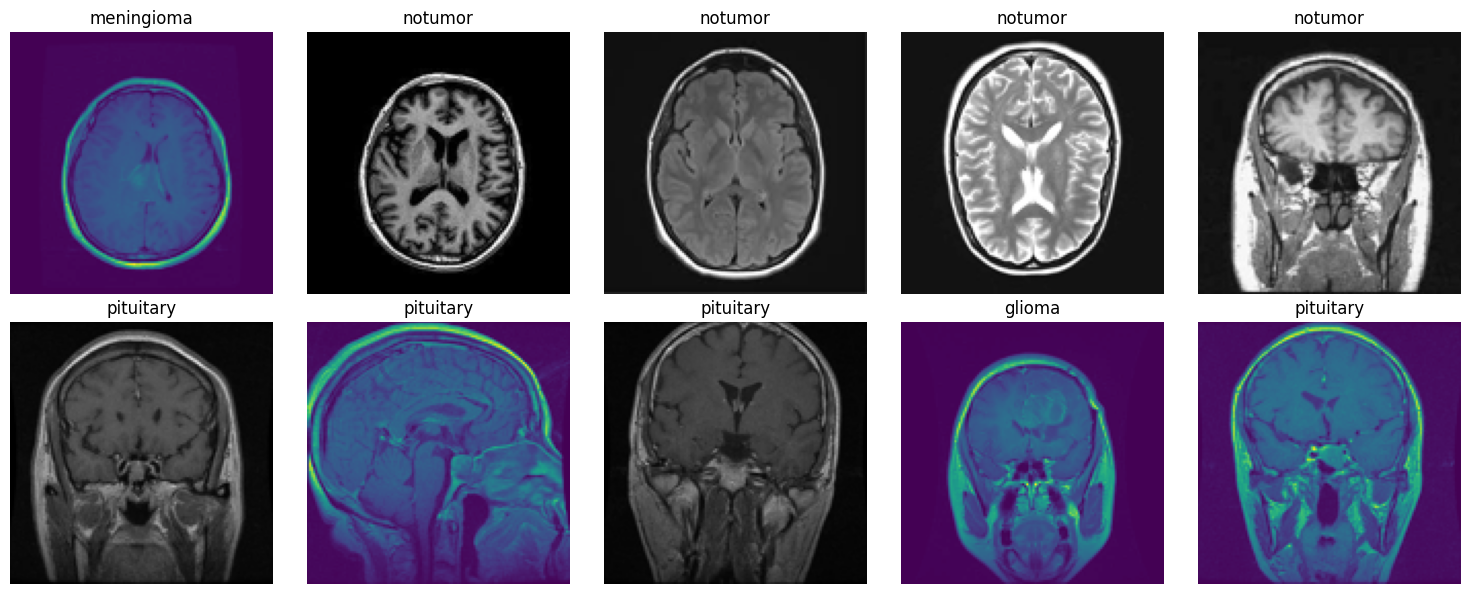

In [4]:
import matplotlib.pyplot as plt

#Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)
random_indices

#create a fig to display img in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes =axes.ravel()

#Loop through the random indices and display img
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  #Display img
  axes[i].imshow(img)
  axes[i].axis('off')
  axes[i].set_title(train_labels[idx])

plt.tight_layout()
plt.show()


# Image Preprocessing (helper functions)

In [5]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

# MODEL

**WE ARE GOING TO USE VGG16 FOR TRANSFER LEARNING**

In [6]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Checkpoint — saves the best model to Drive during training
from tensorflow.keras.callbacks import EarlyStopping

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/model_checkpoint.keras',
    save_best_only=True,
    monitor='val_sparse_categorical_accuracy'  # now monitors validation, not training
)

early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    patience=3,
    restore_best_weights=True
)

epochs = 20  # set generously — EarlyStopping will cut it short automatically
val_steps = int(len(val_paths) / batch_size)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    validation_data=datagen(val_paths, val_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_steps=val_steps,
    callbacks=[checkpoint, early_stop]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 2265s 10s/step - loss: 0.5168 - sparse_categorical_accuracy: 0.8050 - val_loss: 0.3831 - val_sparse_categorical_accuracy: 0.8381
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - loss: 0.2528 - sparse_categorical_accuracy: 0.9057 - val_loss: 0.2480 - val_sparse_categorical_accuracy: 0.8964
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - loss: 0.1882 - sparse_categorical_accuracy: 0.9263 - val_loss: 0.1874 - val_sparse_categorical_accuracy: 0.9345
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 108ms/step - loss: 0.1334 - sparse_categorical_accuracy: 0.9523 - val_loss: 0.2737 - val_sparse_categorical_accuracy: 0.9190
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - loss: 0.1083 - sparse_categorical_accuracy: 0.9599 - val_loss: 0.1529 - val_sparse_categorical_accuracy: 0.9488
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - loss: 0.0971 - sparse_categorical_accuracy: 0.96

# Train and Val Plots

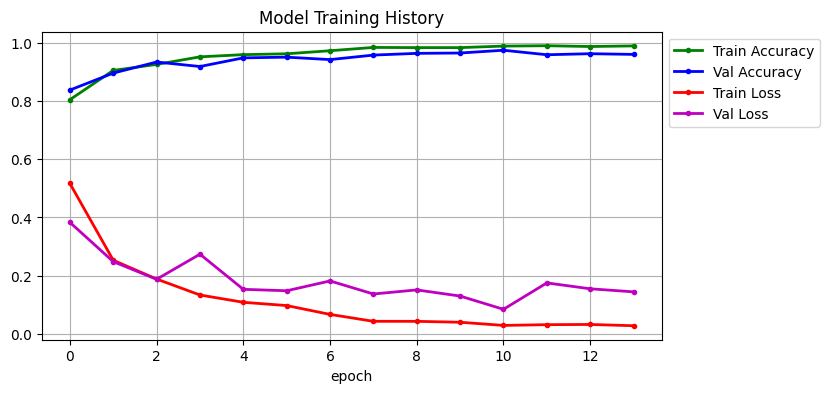

In [7]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], '.b-', linewidth=2, label='Val Accuracy')
plt.plot(history.history['loss'], '.r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'], '.m-', linewidth=2, label='Val Loss')
plt.title('Model Training History')
plt.xlabel('epoch')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       400
           1       0.96      0.99      0.97       400
           2       0.94      0.80      0.86       400
           3       0.89      0.92      0.90       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.92      1600
weighted avg       0.93      0.93      0.92      1600



# Model Confusion Plot

Confusion Matrix:
[[400   0   0   0]
 [  0 395   2   3]
 [ 33   5 318  44]
 [  2  11  18 369]]


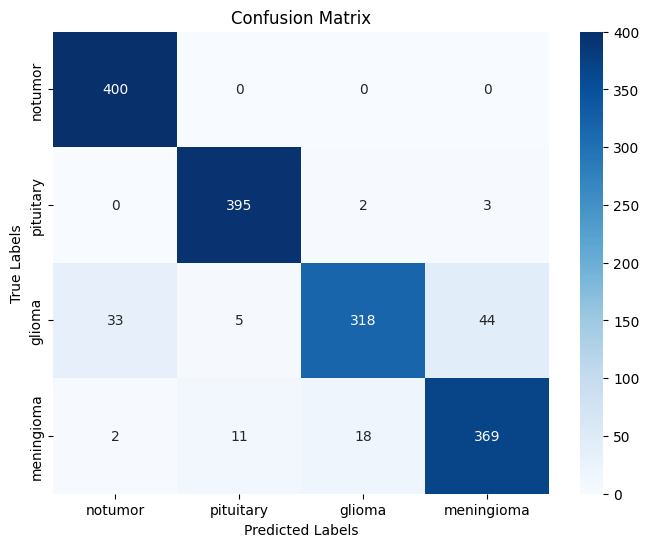

In [10]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot

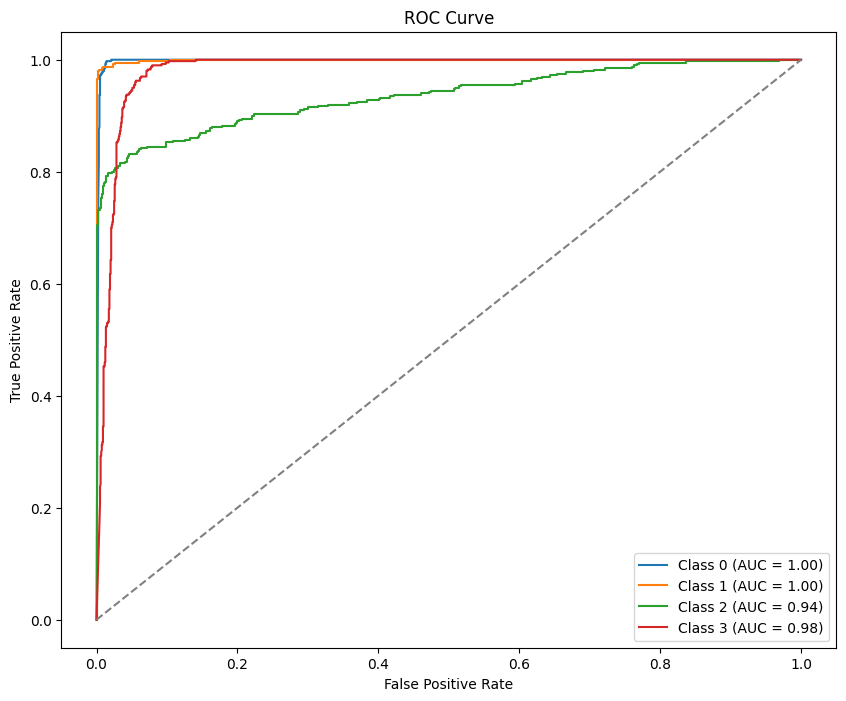

In [11]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Save & Load Model

In [9]:
# Save the entire model to Drive (persistent)
model.save('/content/drive/MyDrive/mri-data/model_final.h5')

from tensorflow.keras.models import load_model
# Load the trained model from Drive
model = load_model('/content/drive/MyDrive/mri-data/model_final.h5')

# Demonstration


In [12]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels — MUST match your actual training order, confirmed via os.listdir(train_dir)
class_labels = ['notumor', 'pituitary', 'glioma', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    confidence_score = np.max(predictions, axis=1)[0]

    if class_labels[predicted_class_index] == 'notumor':
        result = "No Tumor"
    else:
        result = f"Tumor: {class_labels[predicted_class_index]}"

    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


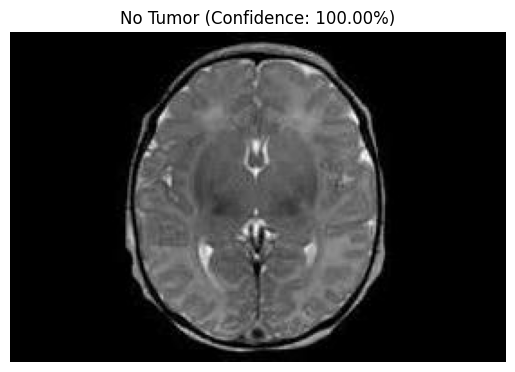

In [13]:
# Test on a real image from your test set — pick any path from test_paths
detect_and_display(test_paths[0], model)

In [14]:
print(test_labels[0])

notumor


In [15]:
print(os.listdir(train_dir))

['notumor', 'pituitary', 'glioma', 'meningioma']
